<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


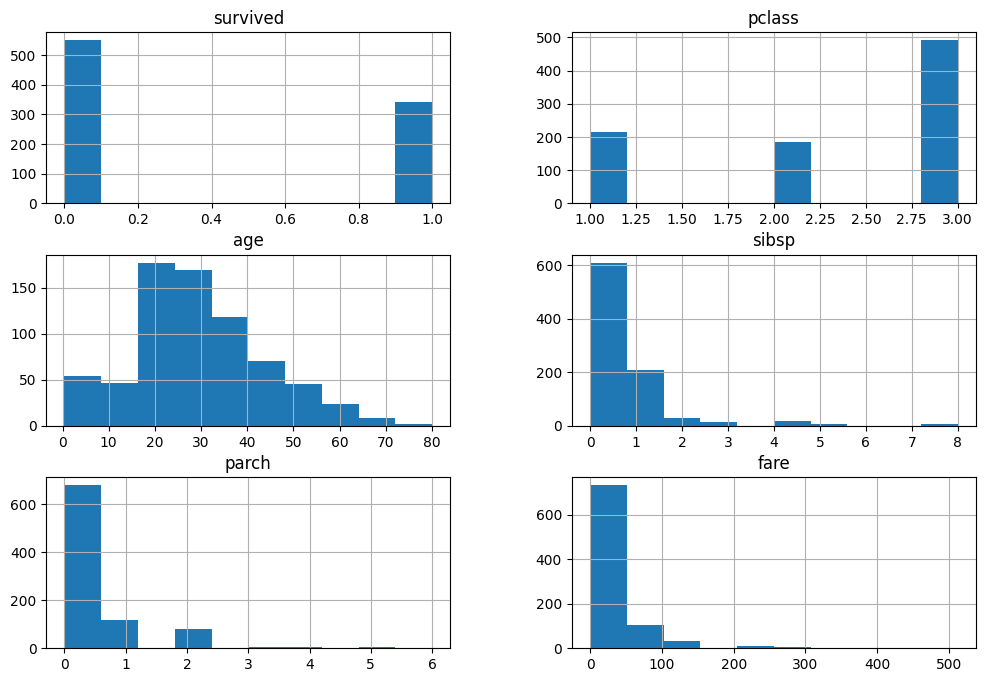

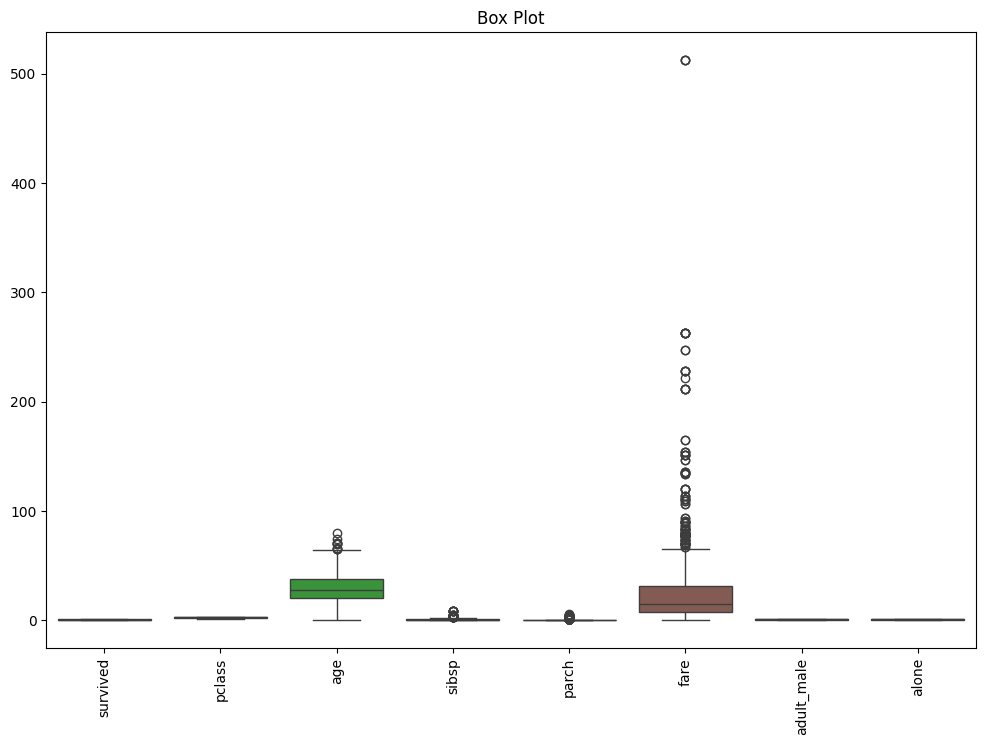

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


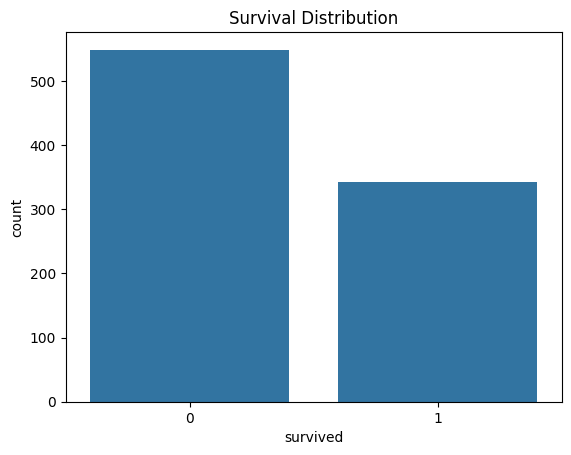

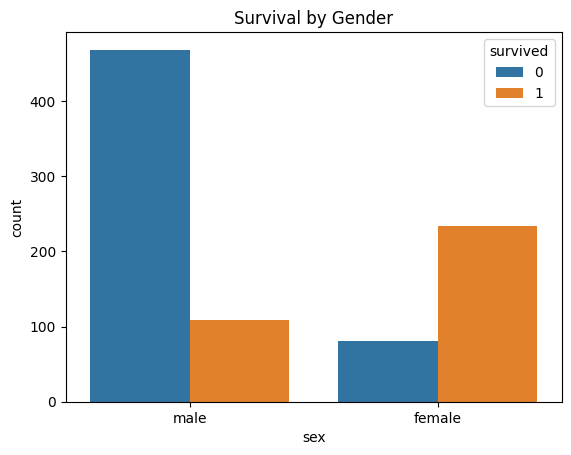

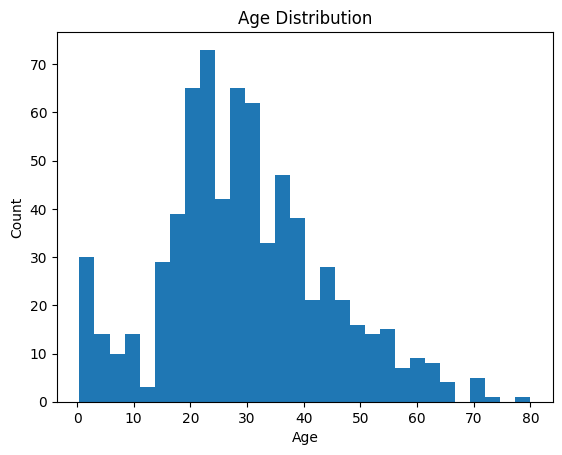

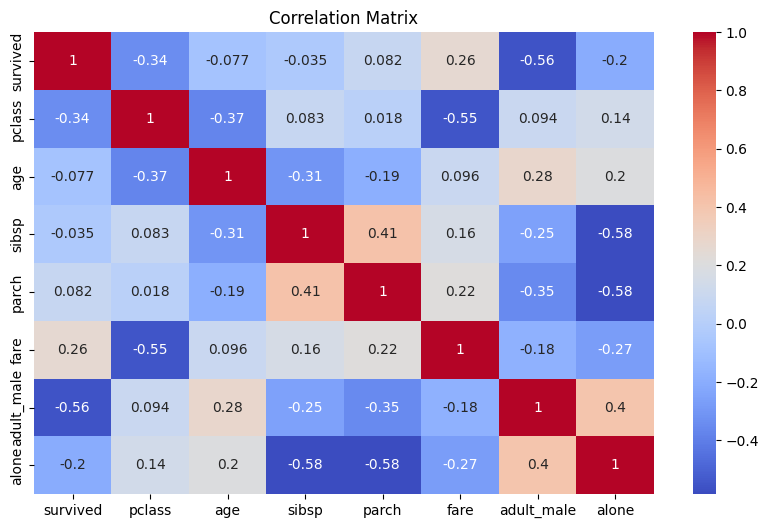

/tmp/ipykernel_7011/2364569273.py:63: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_7011/2364569273.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

Accuracy: 0.7932960893854749

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.64      0.70        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.79       179



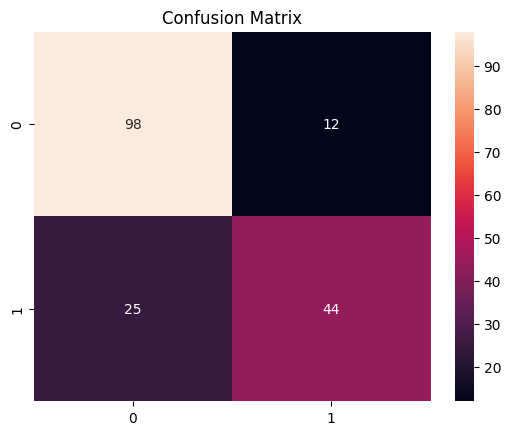

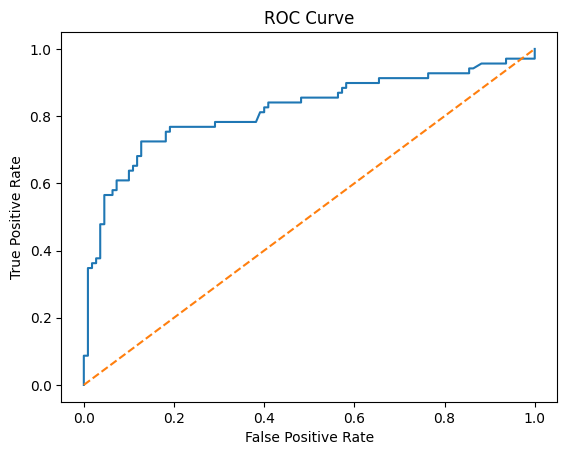

ROC-AUC Score: 0.8176548089591568


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

df.shape

df.info()

df.describe()

df.head()

df.columns

df.isnull().sum()

df.hist(figsize=(12,8))
plt.show()
plt.close('all')

plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.title("Box Plot")
plt.xticks(rotation=90)
plt.show()
plt.close('all')

print(df.isnull().sum())

sns.countplot(x='survived', data=df)
plt.title("Survival Distribution")
plt.show()
plt.close('all')

sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival by Gender")
plt.show()
plt.close('all')

plt.hist(df['age'].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
plt.close('all')

# Removed diabetes-specific zero value imputation as it's not applicable to the Titanic dataset
# cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
# for col in cols:
#     df[col] = df[col].replace(0, df[col].median())

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
plt.close('all')

# --- Data Preprocessing for Model Training ---

# Impute missing 'age' values with the median
df['age'].fillna(df['age'].median(), inplace=True)

# Impute missing 'embarked' values with the mode
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop 'deck' due to a high percentage of missing values
# Drop 'who', 'adult_male', 'alive', 'class', 'embark_town' due to redundancy or high cardinality
df.drop(['deck', 'who', 'adult_male', 'alive', 'class', 'embark_town'], axis=1, inplace=True)

# Encode categorical variables
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

X = df.drop('survived', axis=1)
y = df['survived']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()
plt.close('all')

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()
plt.close('all')
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

In [ ]:
'''
In this assignment, predictive models were built using LightGBM and XGBoost on the Titanic Dataset to predict passenger survival.

During the Exploratory Data Analysis (EDA), the dataset was analyzed to understand feature distributions, identify missing values, and observe relationships between variables such as age, gender, passenger class, and survival status.
Missing values were handled through imputation, and categorical variables were converted into numerical format using encoding techniques.

Both models were trained using the training dataset and evaluated using performance metrics such as accuracy, precision, recall, and F1-score.
Cross-validation and hyperparameter tuning were applied to improve model performance.

Results Interpretation:
LightGBM showed faster training time and handled large datasets efficiently due to its leaf-wise tree growth strategy.
XGBoost provided stable and highly accurate predictions because of its strong regularization and gradient boosting framework.

Practical Implications:
Both algorithms are powerful boosting techniques widely used in machine learning tasks such as classification and regression.
LightGBM is more suitable for large-scale datasets and faster training.
XGBoost is highly reliable and often performs well in structured datasets.

Overall, both models performed effectively for predicting survival on the Titanic dataset,
but the final choice of algorithm may depend on factors such as dataset size, computational resources, and required training speed.
'''